# IND320 – Data to Decision

## Compulsory Assignment 1: Reservoir Data Exploration & Streamlit App

**Name:** Kristian Mathias Røhne
**Course:** IND320 – Data to Decision
**Hand-in:** Part 1 of 4 (Jupyter Notebook + Streamlit App)
**Date:** 22.09.2026

## Links

- **GitHub repository:** https://github.com/kristianrohne/IND320_project_kristianrohne
- **Streamlit app:** https://ind320-project-kristianrohne.streamlit.app/

In [9]:
# Import pandas
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Read the csv file
reservoirs_df = pd.read_csv("data/reservoirs.csv")
reservoirs_df.head()

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


In [17]:
#Renaming the column names:

reservoirs_df = reservoirs_df.rename(columns={
    "dato_Id": "date",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "iso_year",
    "iso_uke": "iso_week",
    "fyllingsgrad": "fill_ratio",
    "kapasitet_TWh": "capacity_twh",
    "fylling_TWh": "filling_twh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "fill_ratio_previous_week",
    "endring_fyllingsgrad": "fill_ratio_change",
})

### Comments:
There are 14877 rows (samples) and 11 columns. I´ve renamed the column names to english names 

# Plot each column separately.

array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

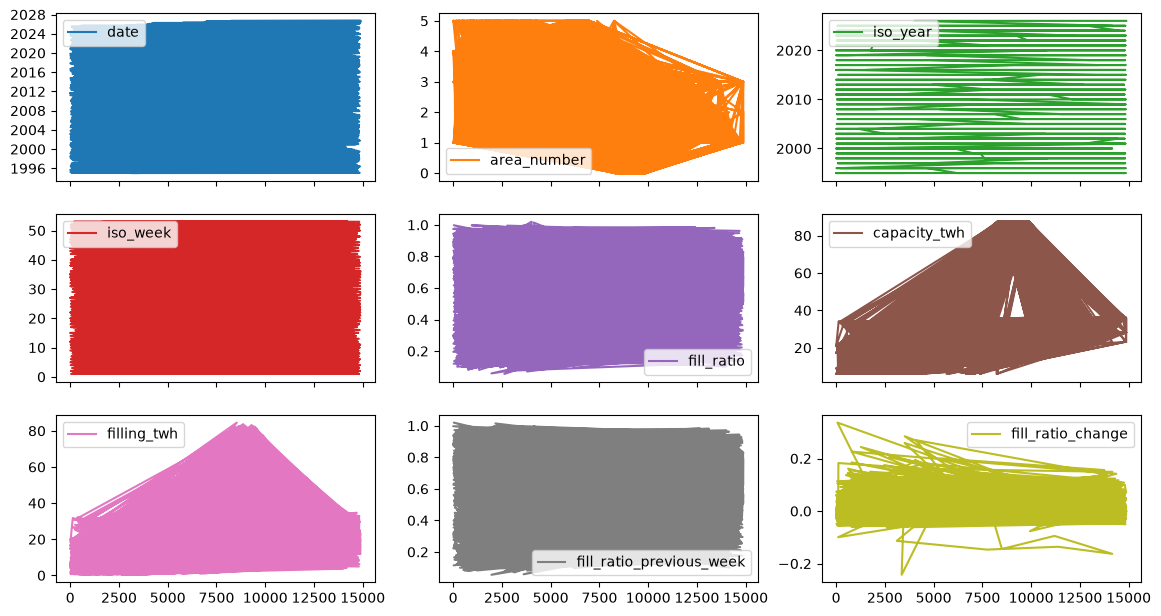

In [19]:
reservoirs_df.plot(subplots=True, layout=(4, 3), figsize=(14, 10))

### Comment:
This was not easy to interpret. I will sort by date and plot for one area at a time 

array([[<Axes: xlabel='date'>, <Axes: xlabel='date'>,
        <Axes: xlabel='date'>],
       [<Axes: xlabel='date'>, <Axes: xlabel='date'>,
        <Axes: xlabel='date'>],
       [<Axes: xlabel='date'>, <Axes: xlabel='date'>,
        <Axes: xlabel='date'>]], dtype=object)

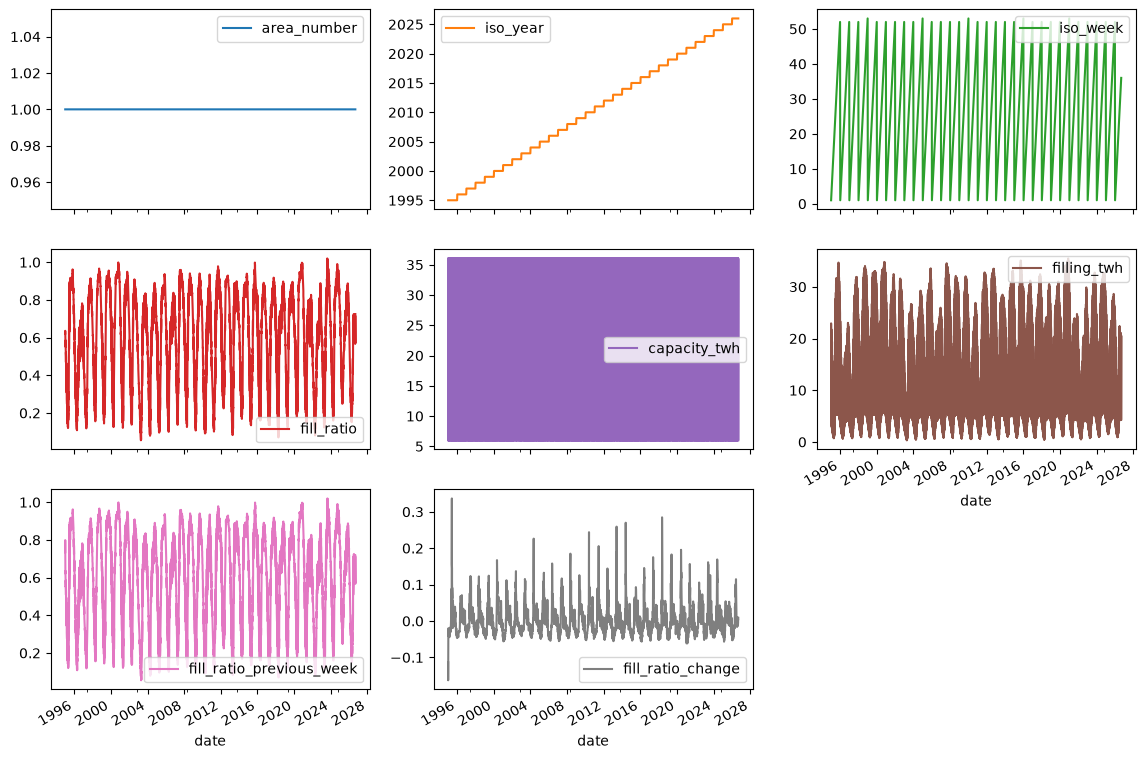

In [ ]:
# Keep just one area
area1_df = reservoirs_df[reservoirs_df["area_number"] == 1]
area1_df = area1_df.sort_values("date").set_index("date")
area1_df.plot(subplots=True, layout=(3, 3), figsize=(14, 10))

## Comment on plots

The dataset contains weekly hydropower reservoir statistics from NVE (Norges vassdrags- 
og energidirektorat), covering Norway's five electricity price areas (NO1–NO5) from 1995 
to the present. Since the raw file interleaves all five areas and is not sorted by date, 
plotting the columns directly produced unreadable, noisy plots. To get a meaningful view, 
the data was filtered down to a single price area (`area_number == 1`) and sorted 
chronologically before plotting.

With that fix, `fill_ratio` and `filling_twh` clearly show the expected seasonal cycle of 
a Nordic hydropower system: reservoirs fill through spring and summer as snow melts and 
rain arrives, then drain through autumn and winter as hydropower is generated and inflow 
drops. `fill_ratio_change` (the week-over-week difference) oscillates around zero, 
spiking during the spring filling season and dropping during the winter drawdown — 
essentially the slope of the `fill_ratio` curve. `iso_week` shows a clean yearly sawtooth 
(1–52, repeating), and `iso_year` is a simple increasing staircase, confirming the sort 
worked correctly. `capacity_twh` is comparatively flat, since it reflects the physical 
storage capacity of the region's reservoirs rather than a fast-changing quantity `area_number` is constant at 1 here since the data has already been 
filtered to a single area.

# Plot all columns together.

<Axes: xlabel='date'>

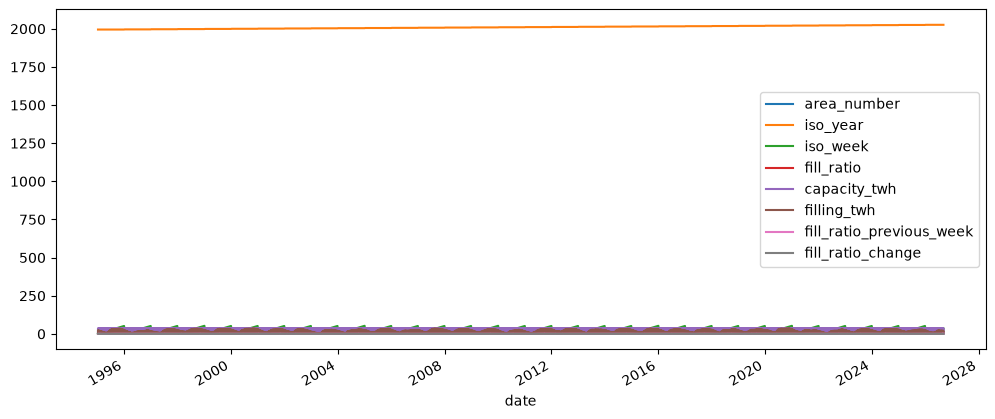

In [ ]:
# Naive attempt: plot everything together, without addressing scale differences
# Just to show what happens
area1_df.plot(figsize=(12, 5))

<Axes: xlabel='date'>

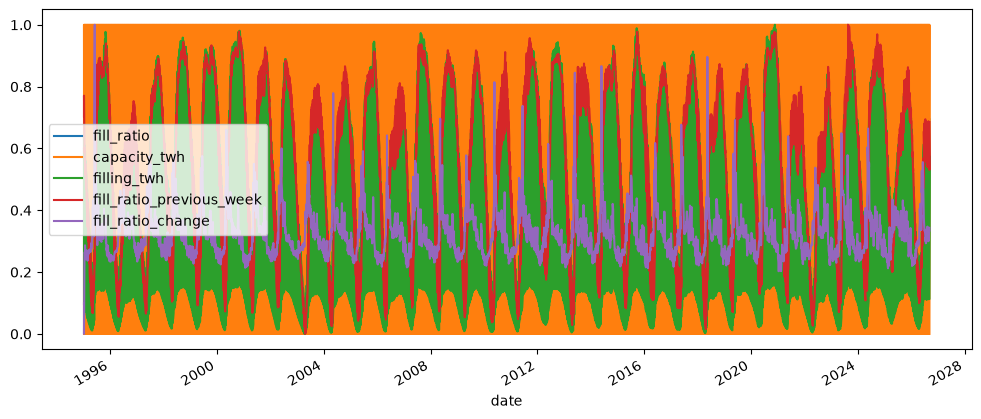

In [ ]:
# excluding `area_number`, `iso_year`, and `iso_week`
cols_to_plot = ["fill_ratio", "capacity_twh", "filling_twh", "fill_ratio_previous_week", "fill_ratio_change"]
# min-max normalzing remaining columns 
normalized_df = (area1_df[cols_to_plot] - area1_df[cols_to_plot].min()) / (area1_df[cols_to_plot].max() - area1_df[cols_to_plot].min())

normalized_df.plot(figsize=(12, 5))

### Comment on plots

A first attempt at plotting every column together on one axis (see plot above) shows why 
this doesn't work naively: `iso_year` has values around 2000, while most of the other 
columns range between 0 and 1 or up to ~36. On a shared linear axis, `iso_year` dominates 
the scale entirely, flattening everything else into an unreadable line near zero.

To make a meaningful combined plot, two changes were made. First, `area_number`, 
`iso_year`, and `iso_week` were excluded — these are identifiers and time components 
rather than measured signals, and aren't meaningfully comparable to reservoir metrics 
like fill ratio or stored energy. Second, the remaining columns (`fill_ratio`, 
`capacity_twh`, `filling_twh`, `fill_ratio_previous_week`, `fill_ratio_change`) were 
min-max normalized to a shared 0–1 range, so differences in absolute units (fractions vs. 
terawatt-hours) don't prevent visual comparison of their relative movement over time.

The result is more readable, though not perfect: `capacity_twh` changes rarely and stays 
close to its historical maximum most of the time, so after normalization it sits pinned 
near 1.0 for long stretches and visually dominates the top of the plot — a reminder that 
min-max scaling compresses slow-moving, low-variance columns less usefully than 
fast-oscillating ones like `fill_ratio`.

## AI Usage

I used Claude (Anthropic) as a learning aid throughout this hand-in, not as a code 
generator. It helped me locate and understand relevant examples already present in the 
IND320 course material, debug tooling issues I ran into along the way (git, uv/venv, VS 
Code setup), and understand my data before plotting it, which caught a few real 
misunderstandings early. I also used it as a sounding board to discuss findings — for 
example interpreting patterns and trends in the plots — and to help polish the language 
in written sections like this one. It also helped me keep track of progress across this 
multi-step task — breaking the assignment down, keeping an overview of what was done 
versus what was next, and reviewing code I had written myself rather than writing it for 
me. Where I explicitly asked for a code snippet, Claude wrote it directly; otherwise I 
wrote, ran, and committed everything myself.

## Development Log

This hand-in started with setting up the basic infrastructure: a public GitHub repository and a Streamlit Community Cloud deployment, tested early with a minimal working example before building out real functionality. I switched to uv for dependency management partway through, since this project will grow across the semester and uv's lockfile-based workflow felt like a better fit than a plain venv — this also meant confirming that Streamlit Cloud correctly picks up uv.lock for deployment. I also chose uv since I haven´t used it before, and I thought it would be nice to experience an alternative to classic .venv. 

In the notebook, I read reservoirs.csv with pandas and renamed its Norwegian column headers to English equivalents (e.g. fyllingsgrad → fill_ratio). Early attempts at plotting the data produced noisy, uninterpretable charts, which led to an important realization about the dataset: it interleaves five separate price areas (NO1–NO5) and isn't reliably sorted by date. Plotting required first sorting by date and filtering down to a single area before the trends became meaningful. I plotted each numeric column separately using subplots, then combined them into a single chart — which required min-max normalizing the columns first, since they're on very different scales (percentages vs. TWh). I also deliberately excluded non-measurement columns like area_number and iso_week from that combined plot, since they aren't meaningful trends to compare.

The Streamlit app took longer, mostly due to debugging. I hit several rounds of issues on the plot page specifically: confusing a selectbox's returned string with an actual dataframe, normalizing a list of column names instead of the underlying data, forgetting that st.pyplot() is required to actually render a matplotlib figure in Streamlit, and not setting date as the index before plotting, which produced a chart with a meaningless numeric x-axis instead of time. Each of these taught me something about the distinction between labels/names and the data they refer to, which is a mistake I made more than once in different forms. I also worked through some tooling friction along the way — a stale git lock file, a .gitignore mistake that would have excluded my data from the repo, and getting VS Code to recognize the right Python interpreter.

To avoid duplicating data-loading logic across pages, I factored it into a shared data_utils.py module with a single cached function, which both the table and plot pages import. This should also make it easier to swap the CSV source for MongoDB in part 2, since only that one function needs to change.

Overall, most of the real learning came from debugging rather than writing code from scratch — understanding why something failed usually taught me more about pandas and Streamlit than getting it right on the first try would have.